# A More Demanding Runge–Kutta Example

The preceding notebook introduced RK1 through RK4 using an equation whose solution changes gently over one time step. Here we deliberately choose a more difficult initial-value problem:

$$
\frac{dy}{dt}=t y^2, \qquad y(0)=100.
$$

Its exact solution is

$$
y(t)=\frac{100}{1-50t^2}=-\frac{2}{t^2-0.02}.
$$

This notebook is about **numerical modeling**, not about adaptive step-size algorithms. We will use fixed steps to explore three important questions:

1. Does a higher-order method automatically make a large step trustworthy?
2. How does the step size affect the numerical result?
3. Why can a mathematically correct algorithm still give a poor answer near rapidly changing behavior?

The example is intentionally severe: the exact solution becomes infinite at $t=\sqrt{0.02}\approx0.1414$, and we integrate to $t=0.14$, just before that singularity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def derivative(t, y):
    """Return dy/dt = t y^2."""
    return t * y**2

def exact_solution(t):
    """Exact solution satisfying y(0) = 100."""
    return 100.0 / (1.0 - 50.0 * np.asarray(t)**2)

t0 = 0.0
y0 = 100.0
t_end = 0.14
t_singularity = np.sqrt(0.02)

print(f"Endpoint:             t = {t_end:.5f}")
print(f"Singularity:          t = {t_singularity:.5f}")
print(f"Exact endpoint value: y = {exact_solution(t_end):.1f}")

Endpoint:             t = 0.14000
Singularity:          t = 0.14142
Exact endpoint value: y = 5000.0


## Why this problem is challenging

The curve begins with zero slope because $dy/dt=ty^2=0$ at $t=0$. Near $t=0.14$, however, both $y$ and the slope $ty^2$ have become enormous. A method that samples only a few slopes over this interval has very little information about that late, rapid rise.

This is a useful warning: **a small initial slope does not imply that a large step will be safe**. The behavior throughout the interval matters.

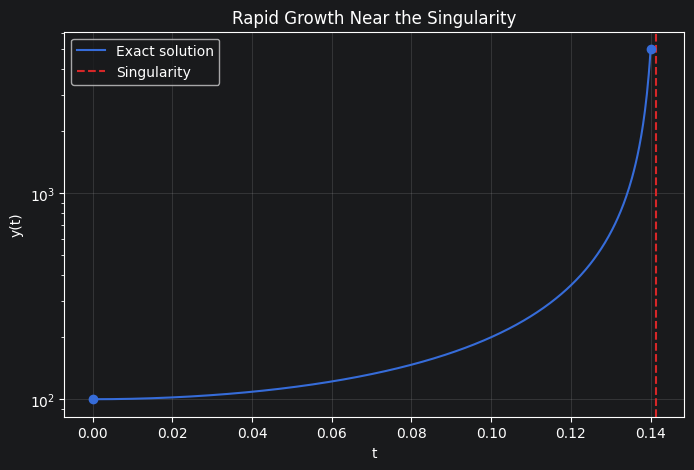

In [2]:
t_plot = np.linspace(t0, t_end, 600)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_plot, exact_solution(t_plot), label="Exact solution")
ax.axvline(t_singularity, color="tab:red", linestyle="--", label="Singularity")
ax.scatter([t0, t_end], [y0, exact_solution(t_end)], zorder=3)
ax.set(xlabel="t", ylabel="y(t)", title="Rapid Growth Near the Singularity")
ax.set_yscale("log")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Four fixed-step Runge–Kutta methods

Each method below advances a state $(t_n,y_n)$ by one step of width $h$. The symbols $k_i$ are slope evaluations; they are not increments in $y$ until they are multiplied by $h$.

- **RK1 (Euler):** uses the slope at the beginning of the interval.
- **RK2 (Heun):** averages the beginning slope and a trial slope at the end.
- **RK3 (Kutta):** combines three slopes with weights $1,4,1$.
- **RK4 (classical):** combines four slopes with weights $1,2,2,1$.

These are standard formulas. In particular, classical RK4 evaluates its two middle slopes at $t_n+h/2$; there is no adjustable internal “divisor.”

In [3]:
def rk1_step(t, y, h):
    k1 = derivative(t, y)
    return y + h * k1

def rk2_step(t, y, h):
    k1 = derivative(t, y)
    k2 = derivative(t + h, y + h * k1)
    return y + h * (k1 + k2) / 2.0

def rk3_step(t, y, h):
    k1 = derivative(t, y)
    k2 = derivative(t + h/2, y + h*k1/2)
    k3 = derivative(t + h, y - h*k1 + 2*h*k2)
    return y + h * (k1 + 4*k2 + k3) / 6.0

def rk4_step(t, y, h):
    k1 = derivative(t, y)
    k2 = derivative(t + h/2, y + h*k1/2)
    k3 = derivative(t + h/2, y + h*k2/2)
    k4 = derivative(t + h, y + h*k3)
    return y + h * (k1 + 2*k2 + 2*k3 + k4) / 6.0

methods = {"RK1": rk1_step, "RK2": rk2_step, "RK3": rk3_step, "RK4": rk4_step}

## First experiment: one very large step

We first ask every method to cross the entire interval from $t=0$ to $t=0.14$ in a single step. This is an intentionally unreasonable demand. It isolates an important distinction:

- **Order** describes how quickly the error decreases as $h$ becomes small.
- It does **not** guarantee accuracy when $h$ is large compared with the scale on which the solution changes.

The relative error reported below is

$$
\text{relative error}=\frac{|y_{\mathrm{numerical}}-y_{\mathrm{exact}}|}{|y_{\mathrm{exact}}|}\times100\%. 
$$

In [4]:
exact_endpoint = float(exact_solution(t_end))
print(f"{'Method':<8}{'Estimate':>14}{'Relative error':>18}")
print("-" * 40)

for name, step in methods.items():
    estimate = step(t0, y0, t_end - t0)
    relative_error = abs(estimate - exact_endpoint) / abs(exact_endpoint) * 100
    print(f"{name:<8}{estimate:>14.3f}{relative_error:>17.3f}%")

Method        Estimate    Relative error
----------------------------------------
RK1            100.000           98.000%
RK2            198.000           96.040%
RK3            451.546           90.969%
RK4            534.635           89.307%


Even RK4 badly underestimates the endpoint. That is not a failure of RK4: it is a failure of our choice to represent an extremely curved solution with only one step. Higher order helps, but it cannot manufacture information about behavior that was never adequately sampled.

## Repeating the method with smaller steps

To integrate over an interval, we apply the one-step rule repeatedly. If the interval is divided into $N$ equal pieces, then

$$
h=\frac{t_{\mathrm{end}}-t_0}{N}.
$$

Reducing $h$ means more derivative evaluations and therefore more computational work, but it also allows the numerical trajectory to respond to the rapidly increasing slope.

In [5]:
def integrate_fixed_step(step, t0, y0, t_end, n_steps):
    """Integrate with n_steps equal fixed steps and return the trajectory."""
    h = (t_end - t0) / n_steps
    times = np.linspace(t0, t_end, n_steps + 1)
    values = np.empty(n_steps + 1)
    values[0] = y0

    for i in range(n_steps):
        values[i + 1] = step(times[i], values[i], h)

    return times, values

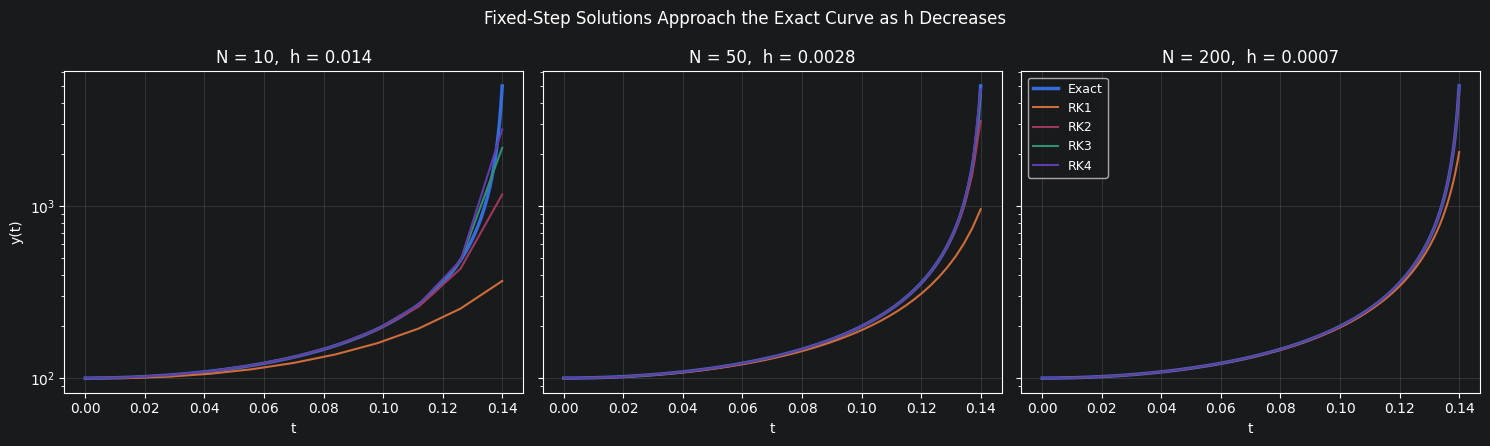

In [6]:
step_counts = [10, 50, 200]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, n_steps in zip(axes, step_counts):
    ax.plot(t_plot, exact_solution(t_plot), linewidth=2.5, label="Exact")
    for name, step in methods.items():
        times, values = integrate_fixed_step(step, t0, y0, t_end, n_steps)
        ax.plot(times, values, label=name)
    ax.set(title=f"N = {n_steps},  h = {t_end/n_steps:.4g}", xlabel="t")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("y(t)")
axes[-1].legend(loc="upper left", fontsize=9)
fig.suptitle("Fixed-Step Solutions Approach the Exact Curve as h Decreases")
fig.tight_layout()
plt.show()

## Endpoint error versus step size

A visual comparison can conceal meaningful differences, so we now measure the endpoint error directly. For a method of order $p$, we expect the global error to behave approximately like

$$
E(h)\propto h^p
$$

once $h$ is sufficiently small. On a log–log plot, this appears as a line whose slope approaches $p$. Near the singularity, however, we may need surprisingly small steps before reaching that asymptotic regime.

Method       error at N=2000      measured slope
------------------------------------------------
RK1                1.521e-01                0.68
RK2                1.074e-03                1.92
RK3                8.701e-06                2.86
RK4                7.713e-08                3.97


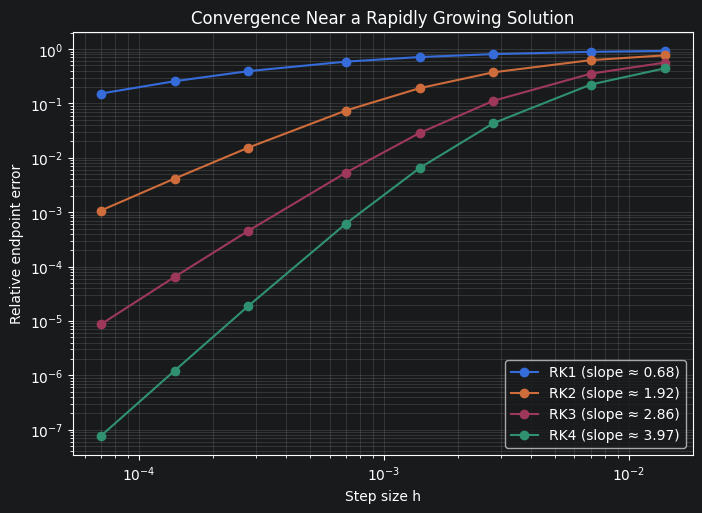

In [7]:
n_values = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])
h_values = (t_end - t0) / n_values

fig, ax = plt.subplots(figsize=(8, 5.5))
print(f"{'Method':<8}{'error at N=2000':>20}{'measured slope':>20}")
print("-" * 48)

for name, step in methods.items():
    errors = []
    for n_steps in n_values:
        _, values = integrate_fixed_step(step, t0, y0, t_end, int(n_steps))
        errors.append(abs(values[-1] - exact_endpoint) / abs(exact_endpoint))
    errors = np.array(errors)
    slope = np.polyfit(np.log(h_values[-3:]), np.log(errors[-3:]), 1)[0]
    print(f"{name:<8}{errors[-1]:>20.3e}{slope:>20.2f}")
    ax.loglog(h_values, errors, "o-", label=f"{name} (slope ≈ {slope:.2f})")

ax.set(xlabel="Step size h", ylabel="Relative endpoint error",
       title="Convergence Near a Rapidly Growing Solution")
ax.grid(which="both", alpha=0.25)
ax.legend()
plt.show()

## What should we learn from this example?

1. **A method and a step size must be judged together.** “RK4” by itself is not an accuracy guarantee.
2. **Higher order becomes powerful when the steps are sufficiently small.** In the convergence plot, RK3 and RK4 eventually gain accuracy much faster than RK1 and RK2.
3. **Rapid variation is numerically demanding.** As the solution approaches its singularity, the relevant time scale becomes much shorter than the full integration interval.
4. **An exact solution is a diagnostic luxury.** We used it to measure error, but in a realistic problem it is usually unavailable. Step-refinement studies—repeating a calculation with smaller $h$—are therefore an essential modeling tool.
5. **Do not tune the RK formula to a known answer.** Changing the internal RK4 coefficients until one endpoint agrees with the exact solution does not create a valid adaptive method; it creates a problem-specific fit.

Adaptive step sizing is a valuable later topic: it estimates local error and changes $h$ while preserving the RK method itself. It is not needed for the present lesson. For the standard RK4 implementation used elsewhere in the course, and notes about the separate adaptive routine, see [`rk_functions.ipynb`](rk_functions.ipynb).